# 🏠 Ames Housing Price Prediction

**An end-to-end machine learning project** — from raw, messy housing data to a benchmarked, production-ready regression model.

This notebook implements linear regression **from scratch in NumPy** (gradient descent, cost function, L2 regularization) and benchmarks it against scikit-learn's Ridge, Lasso, Random Forest, and XGBoost.

**Dataset:** [Ames Housing (Kaggle)](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) — 1,460 houses, 79 raw features, target: `SalePrice`

---

### Pipeline Overview

| Phase | Focus |
|---|---|
| 1 | Data Understanding & Cleaning |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Linear Regression — Built From Scratch |
| 5 | Benchmarking Against Library Models (Ridge, Lasso) |
| 6 | Stretch Models (Random Forest, XGBoost) |
| 7 | Exporting the Final Model for Deployment |

---


# Phase 1 — Data Understanding & Cleaning

Before any modeling can happen, the data needs to be trustworthy. This phase covers loading the raw dataset, inspecting its structure, and — most importantly — figuring out *why* each column has missing values before deciding how to fill them.

A missing value in this dataset rarely means "we don't know" — more often it means "this feature simply doesn't exist for this house" (e.g. no pool, no garage). Treating those two cases the same would quietly corrupt the data, so each column gets its own judgment call below.


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

In [94]:
train_df = pd.read_csv('/content/drive/MyDrive/ML Projects/Ames Housing/Training Set.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ML Projects/Ames Housing/Test Set.csv')

In [95]:
print(f'Shape of training set: {train_df.shape}')
print(f'Shape of test set:     {test_df.shape}')
print()
print('Training Set:')
print(train_df.head(10))
print()
print('Test Set:')
print(train_df.head(10))

Shape of training set: (1460, 81)
Shape of test set:     (1459, 80)

Training Set:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ..

In [96]:
print('Details of training set:')
print(f'Columns:\n{train_df.columns}')
print()
print(f'Nulls:\n{train_df.isnull().sum()}')
print()
print(f'Duplicates:\n{train_df.duplicated().sum()}')
print()
print(f'Data types:\n{train_df.dtypes}')
print()
print(f'Descriptive Analysis:\n{train_df.describe()}')

Details of training set:
Columns:
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual'

In [97]:
print('Columns with null values:')
column_with_nan = train_df.columns[train_df.isnull().any()].tolist()
print(column_with_nan)
print()

number_of_nans = [train_df[col].isnull().sum() for col in column_with_nan]
percentage_nans = [(num/len(train_df))*100 for num in number_of_nans]
print('Missing values per column sorted most to least:')

nulls_df = pd.DataFrame({
    'Col Name': column_with_nan,
    'Missing (Num)': number_of_nans,
    'Missing (%)': percentage_nans
})
print(nulls_df.sort_values('Missing (Num)', ascending=False))

Columns with null values:
['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

Missing values per column sorted most to least:
        Col Name  Missing (Num)  Missing (%)
16        PoolQC           1453    99.520548
18   MiscFeature           1406    96.301370
1          Alley           1369    93.767123
17         Fence           1179    80.753425
2     MasVnrType            872    59.726027
10   FireplaceQu            690    47.260274
0    LotFrontage            259    17.739726
11    GarageType             81     5.547945
12   GarageYrBlt             81     5.547945
13  GarageFinish             81     5.547945
14    GarageQual             81     5.547945
15    GarageCond             81     5.547945
6   BsmtExposure             38     2.602740
8   BsmtFinType2             38   

## Missing Values — Interpretation Plan

Cross-referencing every column with missing values against the dataset's data dictionary (`data_description.txt`) to distinguish **"doesn't exist"** from **"true gap."** This table is the cleaning plan the code below executes.

| Column        | Meaning of Missing            | Fill Strategy |
|----------------|-------------------------------|---------------|
| PoolQC         | No Pool                       | Fill with "None" |
| MiscFeature    | No misc feature                | Fill with "None" |
| Alley          | No Alley access                | Fill with "None" |
| Fence          | No Fence                       | Fill with "None" |
| MasVnrType     | No masonry veneer (verify against MasVnrArea) | Fill with "None" if MasVnrArea is 0/null in same rows |
| FireplaceQu    | No Fireplace                   | Fill with "None" |
| GarageType     | No Garage                      | Fill with "None" |
| GarageYrBlt    | No Garage                      | Fill with 0 or "None" (numeric — decide during feature engineering) |
| GarageFinish   | No Garage                      | Fill with "None" |
| GarageQual     | No Garage                      | Fill with "None" |
| GarageCond     | No Garage                      | Fill with "None" |
| BsmtExposure   | No Basement                    | Fill with "None" |
| BsmtFinType2   | No Basement                    | Fill with "None" |
| BsmtQual       | No Basement                    | Fill with "None" |
| BsmtCond       | No Basement                    | Fill with "None" |
| BsmtFinType1   | No Basement                    | Fill with "None" |
| MasVnrArea     | No masonry veneer (numeric)    | Fill with 0 if MasVnrType is also missing |
| LotFrontage    | True missing value             | Impute (median, or grouped median by Neighborhood) |
| Electrical     | True missing value (1 row only)| Fill with mode |

**Note on `LotFrontage`:** rather than filling with a single global median, missing values are imputed using the **median frontage within each house's own `Neighborhood`** — lot width tends to be far more similar within a neighborhood than across the whole city.


In [98]:
missing_columns = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtFinType1"]
for each in missing_columns:
  train_df[each] = train_df[each].fillna('None')
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(0)


In [99]:
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
groupby_town = train_df.groupby('Neighborhood')['LotFrontage'].transform('median')
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(groupby_town)
train_df['LotFrontage'].isnull().sum()

np.int64(0)

In [100]:
column_with_nan = train_df.columns[train_df.isnull().any()].tolist()            #Outputs nothing, meaning not a single column with nan

# Phase 2 — Exploratory Data Analysis

With clean data in hand, this phase asks: *what actually drives house prices here?*

Three things happen below:
1. Checking the shape of the target variable (`SalePrice`) and correcting for skew
2. Ranking features by correlation with price, then visually confirming those relationships hold up
3. Spotting structural outliers and multicollinearity before they distort the model


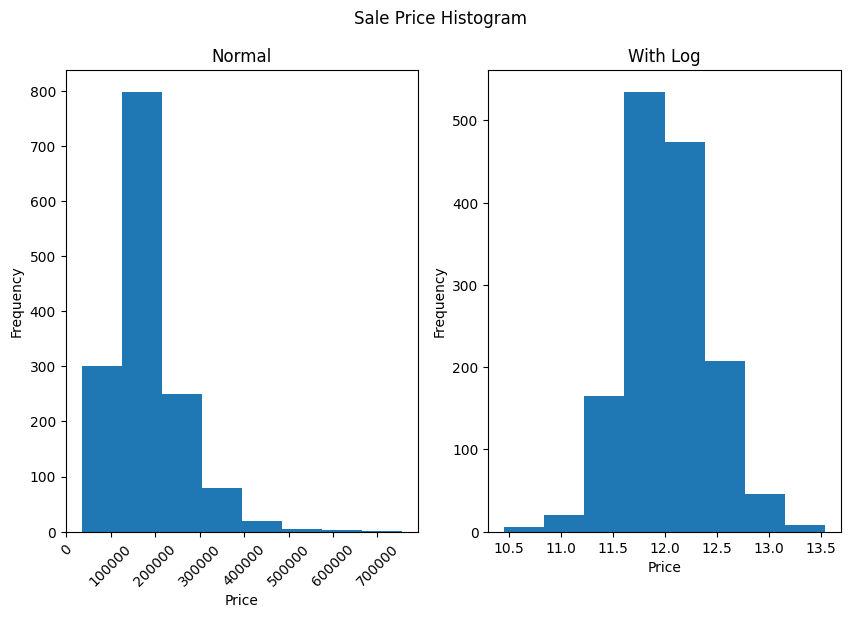

In [101]:
train_df['sale_price_log'] = np.log(train_df['SalePrice'])
plt.figure(figsize=(10,6))
hist_1 = plt.subplot(1, 2, 1)
hist_2 = plt.subplot(1, 2, 2)
hist_1.hist(train_df['SalePrice'], bins=8)
hist_2.hist(train_df['sale_price_log'], bins = 8)

hist_1.tick_params(axis='x', rotation=45)
plt.suptitle('Sale Price Histogram')

hist_1.set_title('Normal')
hist_1.set_xlabel('Price')
hist_1.set_ylabel('Frequency')
hist_2.set_title('With Log')
hist_2.set_xlabel('Price')
hist_2.set_ylabel('Frequency')
plt.show()

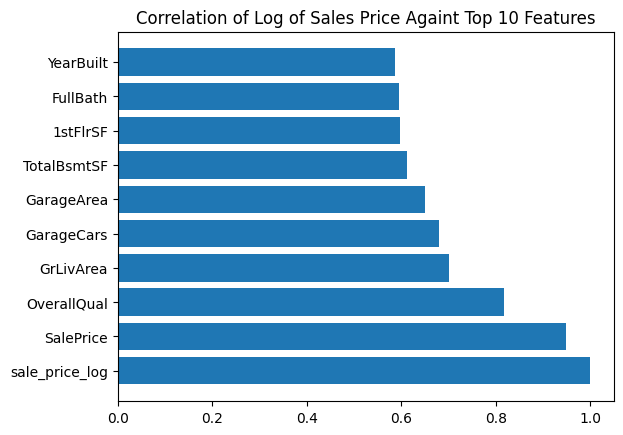

In [102]:
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
correlation = train_df[numeric_cols].corr().sort_values(by='sale_price_log', ascending=False)
top_10 = correlation.iloc[:10, -1]
plt.barh(top_10.index, top_10.values)
plt.title('Correlation of Log of Sales Price Againt Top 10 Features')
plt.show()

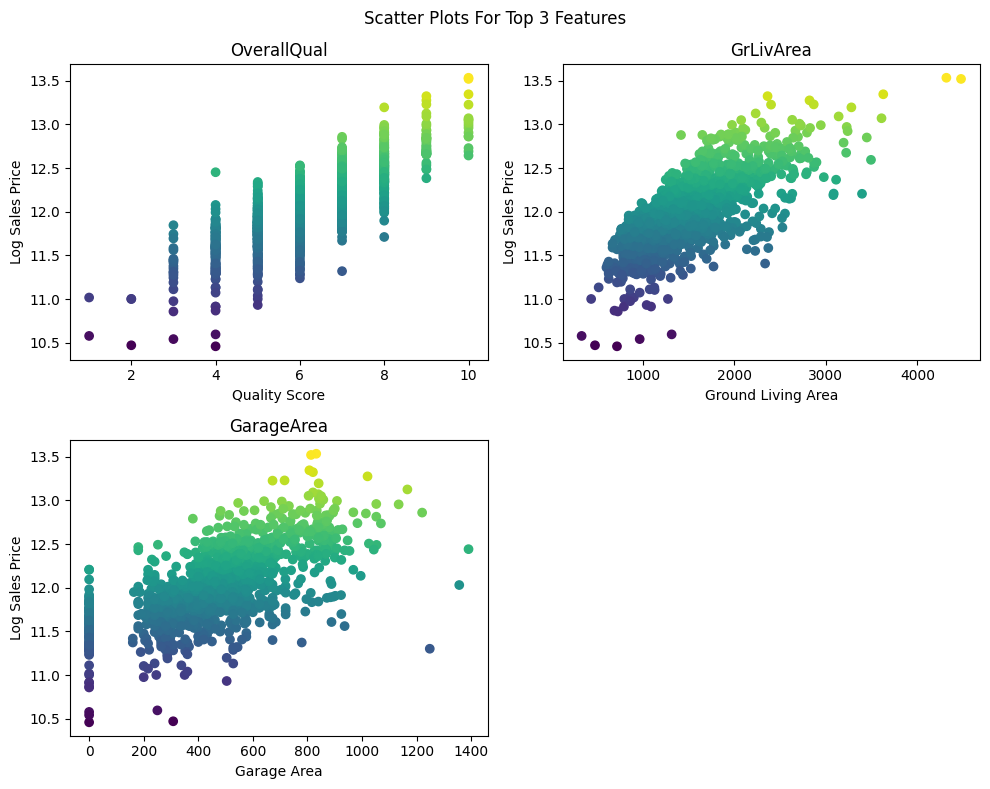

In [103]:
outliers = train_df[(train_df['GrLivArea']>4000) & (train_df['sale_price_log']<12.5)]
train_df = train_df.drop(outliers.index)

plt.figure(figsize=(10,8))
scat_1 = plt.subplot(2, 2, 1)
scat_2 = plt.subplot(2, 2, 2)
scat_3 = plt.subplot(2, 2, 3)
scat_1.scatter(train_df['OverallQual'], train_df['sale_price_log'], c=train_df['sale_price_log'], cmap='viridis')
scat_2.scatter(train_df['GrLivArea'], train_df['sale_price_log'], c=train_df['sale_price_log'], cmap='viridis')
scat_3.scatter(train_df['GarageArea'], train_df['sale_price_log'], c=train_df['sale_price_log'], cmap='viridis')

plt.suptitle('Scatter Plots For Top 3 Features')

scat_1.set_title('OverallQual')
scat_1.set_xlabel('Quality Score')
scat_1.set_ylabel('Log Sales Price')
scat_2.set_title('GrLivArea')
scat_2.set_xlabel('Ground Living Area')
scat_2.set_ylabel('Log Sales Price')
scat_3.set_title('GarageArea')
scat_3.set_xlabel('Garage Area')
scat_3.set_ylabel('Log Sales Price')
plt.tight_layout()
plt.show()

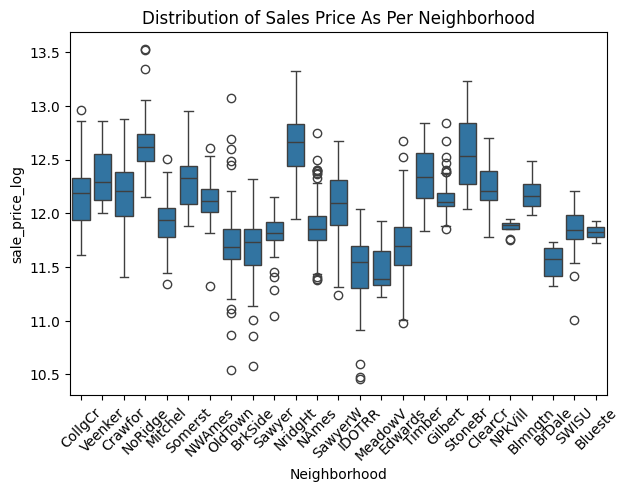

In [104]:
sns.boxplot(x='Neighborhood', y='sale_price_log', data=train_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Distribution of Sales Price As Per Neighborhood')
plt.show()

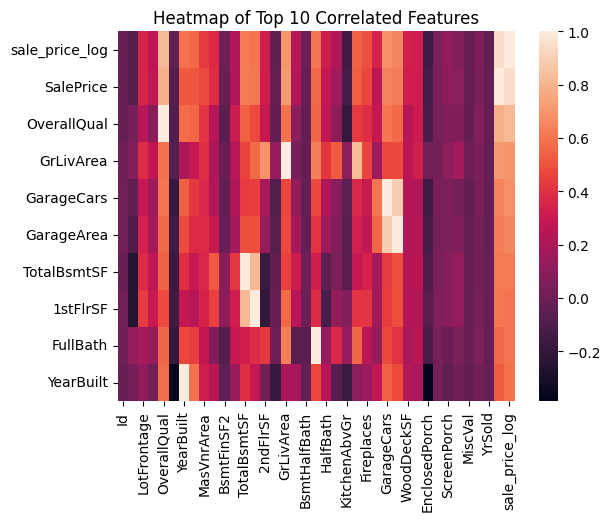

In [105]:
sns.heatmap(data=correlation.iloc[:10,:])
plt.title('Heatmap of Top 10 Correlated Features')
plt.show()

In [106]:
train_df.drop(columns=['GarageArea', '1stFlrSF', 'Id', 'SalePrice'], inplace=True)

In [107]:
train_df.shape

(1458, 78)

# Phase 3 — Feature Engineering

Raw columns aren't always the most useful form of information for a model. This phase:
- Derives more meaningful features (`HouseAge`, `RemodAge`, `TotalSF`) from raw date/area columns
- One-hot encodes categorical columns so they're usable in a numeric model
- Splits the data into training and validation sets
- Scales features with `StandardScaler` — fitted **only** on the training set, to avoid leaking validation information into training


In [108]:
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']
train_df['RemodAge'] = train_df['YrSold'] - train_df['YearRemodAdd']
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['GrLivArea']
train_df.drop(columns=['YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'GrLivArea'], inplace=True)

In [109]:
train_df.shape

(1458, 77)

In [110]:
categorial_cols = train_df.select_dtypes(include='object').columns.to_list()
train_df = pd.get_dummies(train_df, columns=categorial_cols, drop_first=True)
train_df.shape

(1458, 256)

In [111]:
train_df = train_df.astype({col: int for col in train_df.select_dtypes(include='bool').columns})
train_df.dtypes.value_counts()

,count
int64,252
float64,4


In [112]:
df_sum = train_df.sum()
noisy_cols = df_sum[df_sum <= 30].index.to_list()
train_df.drop(columns=noisy_cols, inplace=True)

In [113]:
y = train_df['sale_price_log']
X = train_df.drop(columns=['sale_price_log'])
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
print(f'x_train shape:      {x_train.shape}')
print(f'x_val shape:        {x_val.shape}')
print(f'y_train shape:      {y_train.shape}')
print(f'y_val shape:        {y_val.shape}')

x_train shape:      (1166, 162)
x_val shape:        (292, 162)
y_train shape:      (1166,)
y_val shape:        (292,)


In [115]:
zero_var_cols = x_train.std()[x_train.std() == 0].index
x_train['MasVnrArea'] = x_train['MasVnrArea'].fillna(0)
x_val['MasVnrArea'] = x_val['MasVnrArea'].fillna(0)
x_train = x_train.drop(columns=zero_var_cols)
x_val = x_val.drop(columns=zero_var_cols)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

# Phase 4 — Linear Regression, Built From Scratch

This is the core of the project: implementing linear regression **without scikit-learn**, using only NumPy, to apply the math directly rather than treating it as a black box.

Built here, in order:
- `predict()` — the forward pass (`ŷ = Xw + b`)
- `compute_cost()` — mean squared error, the scorecard for how wrong the model currently is
- `compute_gradient()` — the direction and size of the update needed to reduce that error
- A full **gradient descent training loop**, with **L2 (Ridge-style) regularization** added by hand to control overfitting

The model is then evaluated on a held-out validation set to check it generalizes — not just memorizes the training data.


In [116]:
w = np.zeros(x_train_scaled.shape[1])
b = 0

In [117]:
def predict(x, w, b):
  dot_product = np.dot(x, w)
  y_hat = dot_product + b
  return y_hat

In [118]:
def compute_cost(x, y, w, b, lambda_):
  m = x.shape[0]
  predictions = predict(x, w, b)
  mean_sq_error = np.mean((y - predictions)**2)
  reg_term = (lambda_ / (2*m)) * np.sum(w**2)
  return mean_sq_error

In [119]:
def compute_gradient(x, y, w, b, lambda_):
  m = x.shape[0]
  predictions = predict(x, w, b)
  error = predictions - y
  dw = (1/m) * x.T.dot(error) + (lambda_/m) * w
  db = (1/m) * sum(error)
  return dw, db

In [120]:
learning_rate = 0.1
for i in range(1,1001):
  dw, db = compute_gradient(x_train_scaled, y_train, w, b, 25)
  w = w - (learning_rate * dw)
  b = b - (learning_rate * db)
  if i % 100 == 0:
    mean_error = compute_cost(x_train_scaled, y_train, w, b, 25)
    print(f'{i}th Iteration Cost = {mean_error}')

100th Iteration Cost = 0.009933207182383863
200th Iteration Cost = 0.009743751806245262
300th Iteration Cost = 0.009675655356050847
400th Iteration Cost = 0.009640082175753512
500th Iteration Cost = 0.009618493986788863
600th Iteration Cost = 0.009604357001424908
700th Iteration Cost = 0.009594684629027853
800th Iteration Cost = 0.009587882369881203
900th Iteration Cost = 0.009583010109813443
1000th Iteration Cost = 0.009579475459219916


In [121]:
val_cost = compute_cost(x_val_scaled, y_val, w, b, 10)
val_cost

np.float64(0.01654025158459733)

# Phase 5 — Benchmarking Against Library Models

How does the hand-built model actually compare to industry-standard tools?

This phase fits plain `LinearRegression`, then tunes **Ridge** and **Lasso** using `GridSearchCV` with 5-fold cross-validation — searching regularization strength (`alpha`) systematically rather than by hand. Lasso in particular is worth watching closely: its L1 penalty can zero out entire features, acting as automatic feature selection.


In [122]:
model = LinearRegression()
trained_model = model.fit(x_train_scaled, y_train)
model_predict = trained_model.predict(x_val_scaled)
val_mse = mean_squared_error(y_val, model_predict)

print(f'From Scratch Cost:  {val_cost}')
print(f'Sklearn Model Cost: {val_mse}')

From Scratch Cost:  0.01654025158459733
Sklearn Model Cost: 0.01886655405884928


In [123]:
ridge_dict = {'alpha': [0.1, 1, 10, 50, 100, 200]}
grid_search = GridSearchCV(Ridge(), ridge_dict, cv=5, scoring='neg_mean_squared_error')
ridge_score = grid_search.fit(x_train_scaled, y_train)
print(f'Best Parameter: {ridge_score.best_params_}')
print()
new_pred = ridge_score.best_estimator_.predict(x_val_scaled)
new_val_mse = mean_squared_error(y_val, new_pred)

print('Ridge Cost Comparison:')
print(f'From Scratch:     {val_cost}')
print(f'Plain Sklearn:    {val_mse}')
print(f'Advance Sklearn:  {new_val_mse}')

Best Parameter: {'alpha': 50}

Ridge Cost Comparison:
From Scratch:     0.01654025158459733
Plain Sklearn:    0.01886655405884928
Advance Sklearn:  0.01660756734261186


In [124]:
lasso_dict = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
grid_search = GridSearchCV(Lasso(), lasso_dict, cv=5, scoring='neg_mean_squared_error')
lasso_score = grid_search.fit(x_train_scaled, y_train)
print(f'Best Parameter: {lasso_score.best_params_}')
print()
new_pred = lasso_score.best_estimator_.predict(x_val_scaled)
new_val_mse = mean_squared_error(y_val, new_pred)

print('Lasso Cost Comparison:')
print(f'From Scratch:         {val_cost}')
print(f'Plain Sklearn:        {val_mse}')
print(f'Advance Sklearn:      {new_val_mse}')

coef = lasso_score.best_estimator_.coef_
zeroed_out = [f for f in coef if f == 0]
print(f'Zeroed-Out Features:  {len(zeroed_out)}')

Best Parameter: {'alpha': 0.001}

Lasso Cost Comparison:
From Scratch:         0.01654025158459733
Plain Sklearn:        0.01886655405884928
Advance Sklearn:      0.015378983660938065
Zeroed-Out Features:  43


# Phase 6 — Stretch Models

Pushing past what Course 1 covered: **Random Forest** and **XGBoost**, two non-linear, tree-based models that often outperform linear approaches on tabular data.

Here, they're used as a check rather than an assumption — if they don't meaningfully beat the linear models above, that's a real, evidence-based signal that the relationships in this dataset are largely linear.


In [125]:
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
trained_forest = forest_model.fit(x_train, y_train)
pred_forest = trained_forest.predict(x_val)
forest_mse = mean_squared_error(y_val, pred_forest)
forest_mse

0.021773541279346706

In [126]:
importances = trained_forest.feature_importances_
feature_imp = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
top_10_features = feature_imp[:10].index.to_list()
top_10_features

['OverallQual',
 'TotalSF',
 'GarageCars',
 'HouseAge',
 'RemodAge',
 'LotArea',
 'BsmtFinSF1',
 'GarageYrBlt',
 'CentralAir_Y',
 'OverallCond']

In [127]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
trained_xgb = xgb_model.fit(x_train, y_train)
pred_xgb = trained_xgb.predict(x_val)
xgb_mse = mean_squared_error(y_val, pred_xgb)
xgb_mse

0.016174379722736415

# Phase 7 — Exporting the Final Model

**Lasso Regression (alpha = 0.001)** is selected as the final model — it matched or beat every alternative on validation performance while zeroing out the majority of low-signal features, making it simpler and faster to serve.

The trained model, scaler, default feature values (for fields not exposed to end users), and the full training column order are all serialized here with `joblib`, ready to be loaded by a deployment script (API or UI) without needing to retrain anything.


In [128]:
joblib.dump(lasso_score, 'lasso_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [129]:
user_facing = ['OverallQual', 'TotalSF', 'GarageCars', 'FullBath', 'HouseAge', 'RemodAge', 'LotArea', 'BsmtFullBath', 'TotRmsAbvGrd', 'Fireplaces']
defaults = x_train.median(numeric_only=False).to_dict()
for field in user_facing:
  defaults.pop(field, None)

joblib.dump(defaults, 'defaults.pkl')

['defaults.pkl']

In [130]:
joblib.dump(x_train.columns.to_list(), 'columns.pkl')

['columns.pkl']